<a href="https://colab.research.google.com/github/VictorManuelOrt/Biometric/blob/main/mdpq2204PDM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simulación de Decisión Global con N=3 Agentes
## Estimación del Centroide #4 (2.5, 2.5)

Este notebook implementa:
1. Un entorno con 5 centroides predefinidos en ℝ²
2. 3 agentes que intentan estimar el centroide #4
3. Observaciones con ruido Gaussiano (diferente para cada agente)
4. Dinámica de actualización de creencias
6. Visualización de la evolución de los estados y trayectorias

## 1. Importación de librerías

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')

# Configuración para reproducibilidad
np.random.seed(42)
random.seed(42)

print("Librerías importadas correctamente")

Librerías importadas correctamente


## 2. Definición de los Centroides

Definimos 5 puntos en ℝ² como posibles centros de clúster. El objetivo es estimar el centroide #4.

Centroides definidos:
  Centroide 1: [0. 0.]
  Centroide 2: [5. 0.]
  Centroide 3: [0. 5.]
  Centroide 4: [2.5 2.5] <--- OBJETIVO
  Centroide 5: [5. 5.]


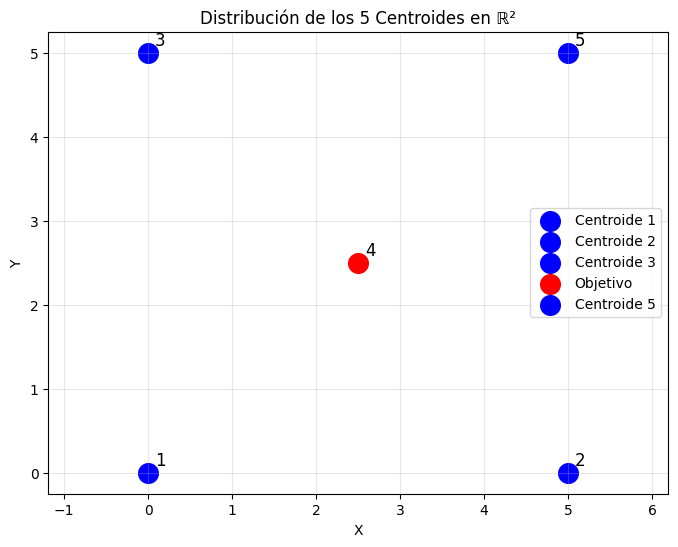

In [ ]:
# Definición de los 5 centroides
centroides = {
    0: np.array([0.0, 0.0]),      # Centroide 1
    1: np.array([5.0, 0.0]),      # Centroide 2
    2: np.array([0.0, 5.0]),      # Centroide 3
    3: np.array([2.5, 2.5]),      # Centroide 4 (OBJETIVO)
    4: np.array([5.0, 5.0])       # Centroide 5
}

centroide_objetivo = 3  # Índice del centroide que queremos estimar (2.5, 2.5)
centroide_objetivo_coords = centroides[centroide_objetivo]

print("Centroides definidos:")
for idx, coord in centroides.items():
    marker = " <--- OBJETIVO" if idx == centroide_objetivo else ""
    print(f"  Centroide {idx+1}: {coord}{marker}")

# Visualización
plt.figure(figsize=(8, 6))
for idx, coord in centroides.items():
    color = 'red' if idx == centroide_objetivo else 'blue'
    plt.scatter(coord[0], coord[1], c=color, s=200, marker='o',
                label=f'Centroide {idx+1}' if idx != centroide_objetivo else 'Objetivo')
    plt.annotate(f'{idx+1}', coord, xytext=(5, 5), textcoords='offset points', fontsize=12)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Distribución de los 5 Centroides en ℝ²')
plt.grid(True, alpha=0.3)
plt.legend()
plt.axis('equal')
plt.show()

## 3. Configuración de los Agentes

Cada agente tiene:
- Parámetros de ruido diferentes para sus observaciones
- Una creencia inicial (puede ser aleatoria o centrada)
- Capacidad de actualizar su creencia mediante observaciones y consultas

In [ ]:
class Agente:
    """Agente con creencia sobre el centroide objetivo"""

    def __init__(self, id_agente, ruido_std, creencia_inicial=None):
        self.id = id_agente
        self.ruido_std = ruido_std  # Desviación estándar del ruido en observaciones

        if creencia_inicial is None:
            # Creencia inicial aleatoria alrededor del centroide objetivo
            self.creencia = centroide_objetivo_coords + np.random.randn(2) * 3.0
        else:
            self.creencia = creencia_inicial.copy()

        self.decision = None  # Almacena la decisión final (índice del centroide)
        self.ha_decidido = False

    def observar(self):
        """
        Simula una observación del centroide objetivo con ruido.
        Retorna: observación (x, y) con ruido Gaussiano
        """
        ruido = np.random.randn(2) * self.ruido_std
        observacion = centroide_objetivo_coords + ruido
        return observacion

    def actualizar_por_observacion(self, observacion, beta=2.0, alpha=0.3):
        """
        Actualización aditiva: combinar creencia con observación.
        Es más intuitiva y preserva la escala.
        """
        # Mover hacia la observación con factor alpha
        self.creencia = (1 - alpha) * self.creencia + alpha * observacion
        return self.creencia

    def consultar(self, otras_creencias):
        """
        Actualiza la creencia consultando a otros agentes.
        Combina las creencias usando un promedio ponderado.
        """
        todas_creencias = [self.creencia] + otras_creencias
        self.creencia = np.mean(todas_creencias, axis=0)
        return self.creencia

    def decidir(self):
        """
        Decide cuál centroide cree que es el correcto
        basado en la distancia mínima a su creencia actual.
        """
        distancias = {idx: np.linalg.norm(self.creencia - centroide)
                     for idx, centroide in centroides.items()}
        self.decision = min(distancias, key=distancias.get)
        self.ha_decidido = True
        return self.decision

    def reset(self):
        """Reinicia el agente para un nuevo episodio"""
        self.creencia = centroide_objetivo_coords + np.random.randn(2) * 2.0
        self.decision = None
        self.ha_decidido = False

## 4. Entorno de Simulación

El entorno gestiona:
- Los 3 agentes
- Las acciones conjuntas
- La función de recompensa
- La evolución del estado

In [ ]:
class EntornoDecisionGlobal:
    """Entorno para simulación de decisión global con N agentes"""

    def __init__(self, N=3, max_pasos=25):
        self.N = N
        self.max_pasos = max_pasos
        self.paso_actual = 0

        # Parámetros de ruido para cada agente (diferentes niveles de precisión)
        ruidos = [0.5, 1.0, 1.5]  # Agente 1 más preciso, Agente 3 menos preciso

        # Crear agentes
        self.agentes = [Agente(i, ruidos[i]) for i in range(N)]

        # Costos de acciones
        self.costos = {
            'esperar': -0.2,
            'observar': -1.0,
            'consultar': -0.5,
            'decidir': 0.0
        }

        # Historial de estados
        self.historial_creencias = []
        self.historial_recompensas = []
        self.historial_acciones = []

    def obtener_estado(self):
        """
        Retorna el estado actual como un vector de 2N dimensiones.
        Incluye las creencias de todos los agentes y flags de decisión.
        """
        estado = []
        for agente in self.agentes:
            estado.extend(agente.creencia)
            estado.append(1.0 if agente.ha_decidido else 0.0)
        return np.array(estado)

    def calcular_recompensa(self, acciones, decisiones_anteriores):
        """
        Calcula la recompensa según la función definida.
        """
        # Costo individual de acciones
        costo_total = sum(self.costos[acc] for acc in acciones)

        # Verificar acuerdos parciales
        decisiones_actuales = [a.decision for a in self.agentes if a.ha_decidido]

        delta_acuerdo = 0
        if len(decisiones_actuales) > 1:
            if len(set(decisiones_actuales)) == 1:
                delta_acuerdo = 30  # Todos los que decidieron coinciden
            else:
                delta_acuerdo = -20  # Hay desacuerdo

        # Verificar final del episodio
        delta_final = 0
        todos_han_decidido = all(a.ha_decidido for a in self.agentes)

        if todos_han_decidido:
            decisiones = [a.decision for a in self.agentes]
            if len(set(decisiones)) == 1:
                delta_final = 100  # Todos coinciden y es correcto
            else:
                delta_final = -100  # Desacuerdo total

        return costo_total + delta_acuerdo + delta_final

    def step(self, acciones_conjuntas):
        """
        Ejecuta un paso en el entorno.

        Parámetros:
        - acciones_conjuntas: lista de strings de longitud N
          Cada string puede ser 'esperar', 'observar', 'consultar', 'decidir'

        Retorna:
        - nuevo_estado: vector de estado actualizado
        - recompensa: recompensa obtenida
        - done: booleano indicando si el episodio terminó
        - info: información adicional
        """
        self.paso_actual += 1

        # Guardar estado antes de la acción
        estado_anterior = self.obtener_estado()

        # Ejecutar acciones
        observaciones_realizadas = []

        for i, accion in enumerate(acciones_conjuntas):
            agente = self.agentes[i]

            if accion == 'observar' and not agente.ha_decidido:
                obs = agente.observar()
                observaciones_realizadas.append(obs)
                agente.actualizar_por_observacion(obs)
            elif accion == 'consultar' and not agente.ha_decidido:
                otras_creencias = [a.creencia for j, a in enumerate(self.agentes)
                                  if j != i and not a.ha_decidido]
                if otras_creencias:
                    agente.consultar(otras_creencias)
            elif accion == 'decidir' and not agente.ha_decidido:
                # Solo puede decidir si su creencia está cerca de algún centroide
                distancias = [np.linalg.norm(agente.creencia - c) for c in centroides.values()]
                if min(distancias) <= 2.0:  # Umbral de decisión que habrá que ajustar
                    agente.decidir()
            # 'esperar' no hace nada

        # Calcular recompensa
        recompensa = self.calcular_recompensa(acciones_conjuntas, None)

        # Verificar si el episodio terminó
        todos_han_decidido = all(a.ha_decidido for a in self.agentes)
        done = todos_han_decidido or self.paso_actual >= self.max_pasos

        # Guardar historial
        self.historial_creencias.append([a.creencia.copy() for a in self.agentes])
        self.historial_recompensas.append(recompensa)
        self.historial_acciones.append(acciones_conjuntas)

        nuevo_estado = self.obtener_estado()

        info = {
            'paso': self.paso_actual,
            'decisiones': [a.decision for a in self.agentes],
            'creencias': [a.creencia.copy() for a in self.agentes]
        }

        return nuevo_estado, recompensa, done, info

    def reset(self):
        """Reinicia el entorno para un nuevo episodio"""
        self.paso_actual = 0
        for agente in self.agentes:
            agente.reset()
        self.historial_creencias = [[a.creencia.copy() for a in self.agentes]]
        self.historial_recompensas = []
        self.historial_acciones = []
        return self.obtener_estado()

    def visualizar_trayectorias(self, titulo="Evolución de las Trayectorias de los Agentes"):
        """
        Visualiza las trayectorias completas de los 3 agentes en un solo gráfico.
        """
        n_pasos = len(self.historial_creencias)

        # Crear figura principal para trayectorias
        plt.figure(figsize=(12, 10))

        # Dibujar centroides
        for idx, coord in centroides.items():
            color = 'gold' if idx == centroide_objetivo else 'gray'
            size = 300 if idx == centroide_objetivo else 150
            marker = '*' if idx == centroide_objetivo else 'o'
            plt.scatter(coord[0], coord[1], c=color, s=size, marker=marker,
                       edgecolors='black', linewidth=2, zorder=5)
            plt.annotate(f'C{idx+1}', coord, xytext=(10, 10), textcoords='offset points',
                        fontsize=12, fontweight='bold')

        # Colores para cada agente
        colores = ['red', 'green', 'blue']
        estilos_linea = ['-', '--', ':']
        nombres = ['Agente 1 (ruido=0.5)', 'Agente 2 (ruido=1.0)', 'Agente 3 (ruido=1.5)']

        # Dibujar trayectorias
        for i in range(3):
            evolucion_x = [creencias[i][0] for creencias in self.historial_creencias]
            evolucion_y = [creencias[i][1] for creencias in self.historial_creencias]

            # Dibujar línea de trayectoria
            plt.plot(evolucion_x, evolucion_y, color=colores[i], linestyle=estilos_linea[i],
                    linewidth=2.5, alpha=0.7, label=nombres[i])

            # Marcar puntos de la trayectoria
            for paso, (x, y) in enumerate(zip(evolucion_x, evolucion_y)):
                if paso == 0:
                    plt.scatter(x, y, c=colores[i], s=150, marker='s',
                              edgecolors='black', linewidth=2, zorder=6)
                elif paso == len(evolucion_x) - 1:
                    plt.scatter(x, y, c=colores[i], s=150, marker='D',
                              edgecolors='black', linewidth=2, zorder=6)
                else:
                    plt.scatter(x, y, c=colores[i], s=50, marker='o', alpha=0.5)

        # Añadir flechas para indicar dirección
        for i in range(3):
            evolucion_x = [creencias[i][0] for creencias in self.historial_creencias]
            evolucion_y = [creencias[i][1] for creencias in self.historial_creencias]
            if len(evolucion_x) > 1:
                for j in range(len(evolucion_x)-1):
                    if j % max(1, len(evolucion_x)//5) == 0:  # Solo algunas flechas
                        dx = evolucion_x[j+1] - evolucion_x[j]
                        dy = evolucion_y[j+1] - evolucion_y[j]
                        plt.arrow(evolucion_x[j], evolucion_y[j], dx*0.5, dy*0.5,
                                 head_width=0.1, head_length=0.1, fc=colores[i], ec=colores[i], alpha=0.3)

        plt.xlabel('Coordenada X', fontsize=12)
        plt.ylabel('Coordenada Y', fontsize=12)
        plt.title(titulo, fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.legend(loc='best', fontsize=10)
        plt.xlim(-3, 8)
        plt.ylim(-3, 8)
        plt.axhline(y=0, color='k', linestyle='-', alpha=0.2)
        plt.axvline(x=0, color='k', linestyle='-', alpha=0.2)
        plt.gca().set_aspect('equal')
        plt.tight_layout()
        plt.show()

    def visualizar_evolucion(self):
        """Visualiza la evolución de las creencias de los agentes en subplots"""
        n_pasos = len(self.historial_creencias)
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        colores = ['red', 'green', 'blue']
        nombres = ['Agente 1', 'Agente 2', 'Agente 3']

        for i in range(3):
            ax = axes[i]

            # Dibujar centroides
            for idx, coord in centroides.items():
                color = 'gold' if idx == centroide_objetivo else 'gray'
                ax.scatter(coord[0], coord[1], c=color, s=100, marker='*',
                          edgecolors='black', linewidth=1)
                if idx == centroide_objetivo:
                    ax.annotate('Objetivo', coord, xytext=(5, 5), textcoords='offset points')

            # Extraer evolución de la creencia del agente i
            evolucion_x = [creencias[i][0] for creencias in self.historial_creencias]
            evolucion_y = [creencias[i][1] for creencias in self.historial_creencias]

            # Dibujar trayectoria
            ax.plot(evolucion_x, evolucion_y, 'o-', color=colores[i],
                   markersize=6, linewidth=2, label=nombres[i])

            # Marcar inicio y fin
            ax.scatter(evolucion_x[0], evolucion_y[0], c=colores[i], s=150,
                      marker='s', edgecolors='black', label='Inicio')
            ax.scatter(evolucion_x[-1], evolucion_y[-1], c=colores[i], s=150,
                      marker='D', edgecolors='black', label='Final')

            # Añadir números de paso
            for paso, (x, y) in enumerate(zip(evolucion_x, evolucion_y)):
                if paso % max(1, len(evolucion_x)//5) == 0:
                    ax.annotate(str(paso), (x, y), xytext=(5, 5), textcoords='offset points',
                               fontsize=8, alpha=0.7)

            ax.set_xlabel('X')
            ax.set_ylabel('Y')
            ax.set_title(f'{nombres[i]} - Ruido STD={self.agentes[i].ruido_std}')
            ax.grid(True, alpha=0.3)
            ax.legend()
            ax.set_xlim(-3, 8)
            ax.set_ylim(-3, 8)

        plt.suptitle(f'Evolución de las Creencias - {n_pasos} pasos', fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # Mostrar recompensas
        print(f"\nRecompensa total del episodio: {sum(self.historial_recompensas):.2f}")
        print(f"Decisiones finales: {[a.decision for a in self.agentes]}")
        print(f"Centroide objetivo: {centroide_objetivo} ({centroide_objetivo_coords})")

        # Gráfico de recompensas por paso
        # Gráfico de recompensas por paso y acumulado
        if self.historial_recompensas:
            fig, axes = plt.subplots(1, 2, figsize=(15, 5))

            # Gráfico 1: Recompensas por paso (original)
            axes[0].plot(range(1, len(self.historial_recompensas)+1), self.historial_recompensas,
                        'bo-', linewidth=2, markersize=8)
            axes[0].set_xlabel('Paso')
            axes[0].set_ylabel('Recompensa')
            axes[0].set_title('Recompensas por paso')
            axes[0].grid(True, alpha=0.3)
            axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)

            # Gráfico 2: Recompensa acumulada (NUEVO)
            recompensa_acumulada = np.cumsum(self.historial_recompensas)
            axes[1].plot(range(1, len(recompensa_acumulada)+1), recompensa_acumulada,
                        'go-', linewidth=2, markersize=8, color='green')
            axes[1].set_xlabel('Paso')
            axes[1].set_ylabel('Recompensa Acumulada')
            axes[1].set_title('Recompensa Acumulada por paso')
            axes[1].grid(True, alpha=0.3)
            axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)

            # Añadir valor final como anotación
            valor_final = recompensa_acumulada[-1]
            axes[1].annotate(f'Total: {valor_final:.2f}',
                            xy=(len(recompensa_acumulada), valor_final),
                            xytext=(-50, 10), textcoords='offset points',
                            fontsize=10, fontweight='bold',
                            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7))

            plt.tight_layout()
            plt.show()

## 5. Simulación del PDM

Primero simulamos el entorno con una política fija para ver la evolución de los estados.

=== SIMULACIÓN CON POLÍTICA FIJA ===

Estado inicial (creencias de los 3 agentes):
  Agente 1: (-0.02, 4.34)
  Agente 2: (6.74, 4.56)
  Agente 3: (-0.54, 1.53)

--- EVOLUCIÓN ---

Paso 1:
  Acciones: ['observar', 'observar', 'observar']
  Recompensa: -3.00
  Creencias actuales:
    Agente 1: (0.92, 3.68)
    Agente 2: (5.60, 4.18)
    Agente 3: (-0.04, 1.80)

Paso 2:
  Acciones: ['observar', 'observar', 'observar']
  Recompensa: -3.00
  Creencias actuales:
    Agente 1: (0.91, 3.17)
    Agente 2: (4.60, 3.30)
    Agente 3: (1.45, 1.36)

Paso 3:
  Acciones: ['observar', 'observar', 'observar']
  Recompensa: -3.00
  Creencias actuales:
    Agente 1: (1.32, 2.99)
    Agente 2: (4.40, 2.63)
    Agente 3: (2.29, 1.71)

Paso 4:
  Acciones: ['observar', 'observar', 'observar']
  Recompensa: -3.00
  Creencias actuales:
    Agente 1: (1.53, 2.91)
    Agente 2: (3.89, 2.41)
    Agente 3: (2.39, 1.77)

Paso 5:
  Acciones: ['observar', 'observar', 'observar']
  Recompensa: -3.00
  Creencias actual

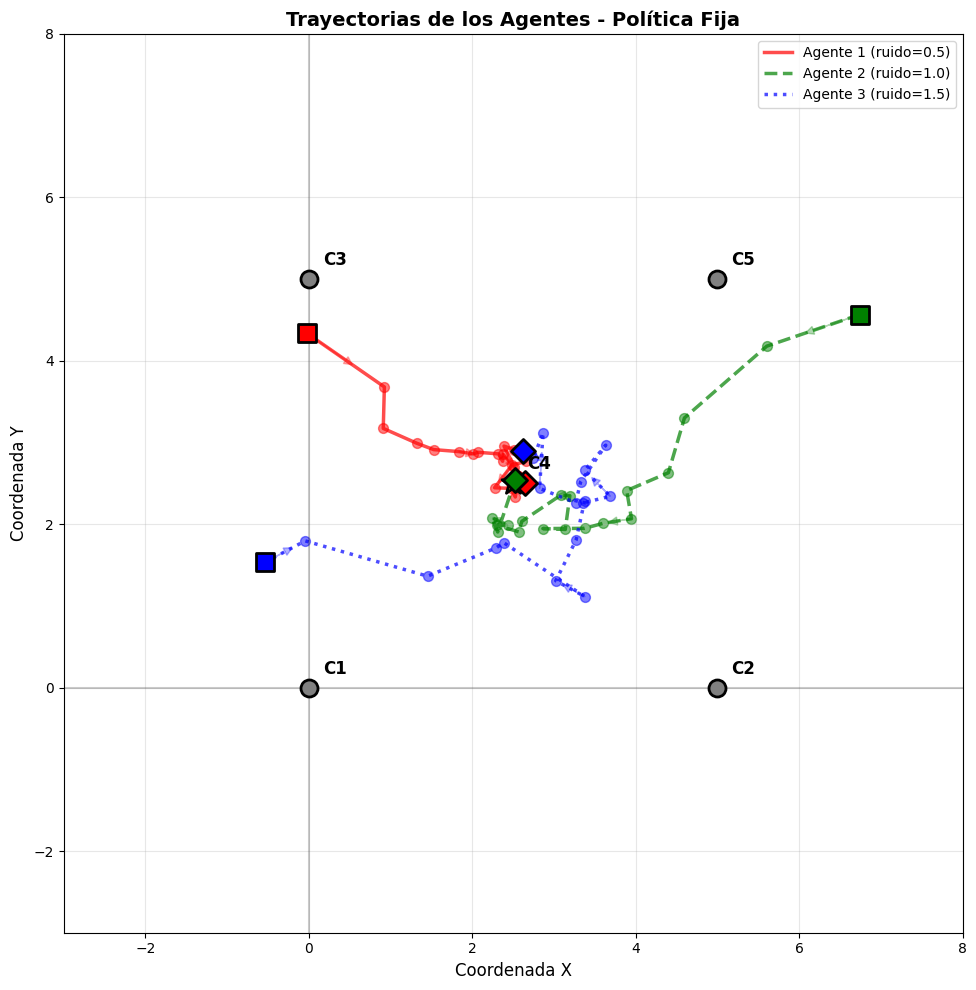

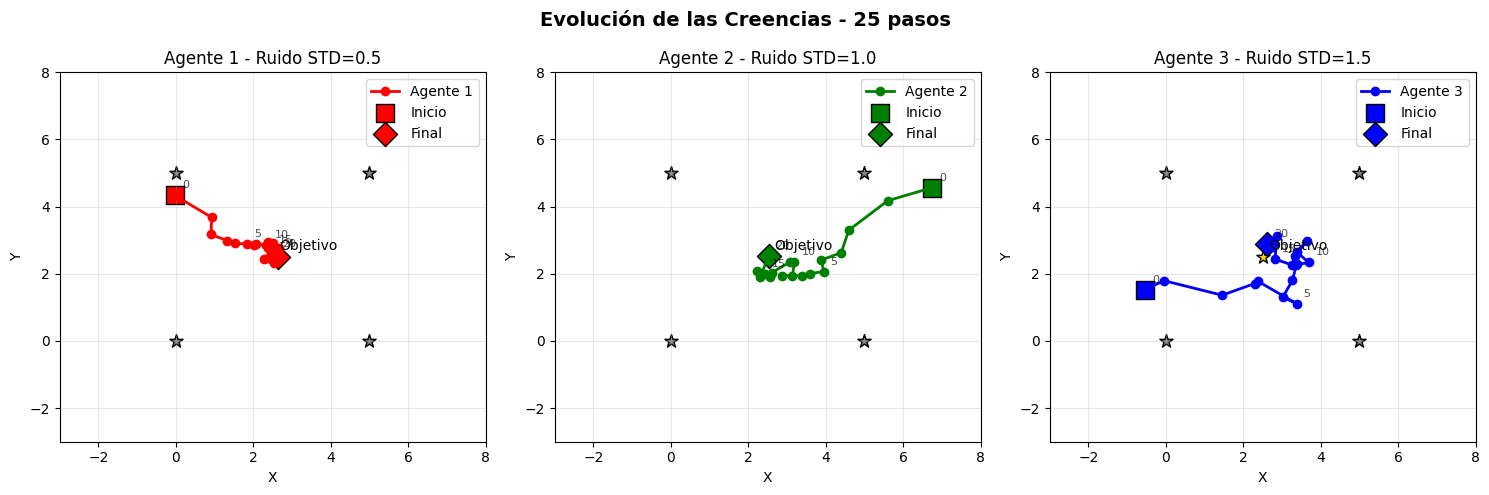


Recompensa total del episodio: 215.00
Decisiones finales: [3, 3, 3]
Centroide objetivo: 3 ([2.5 2.5])


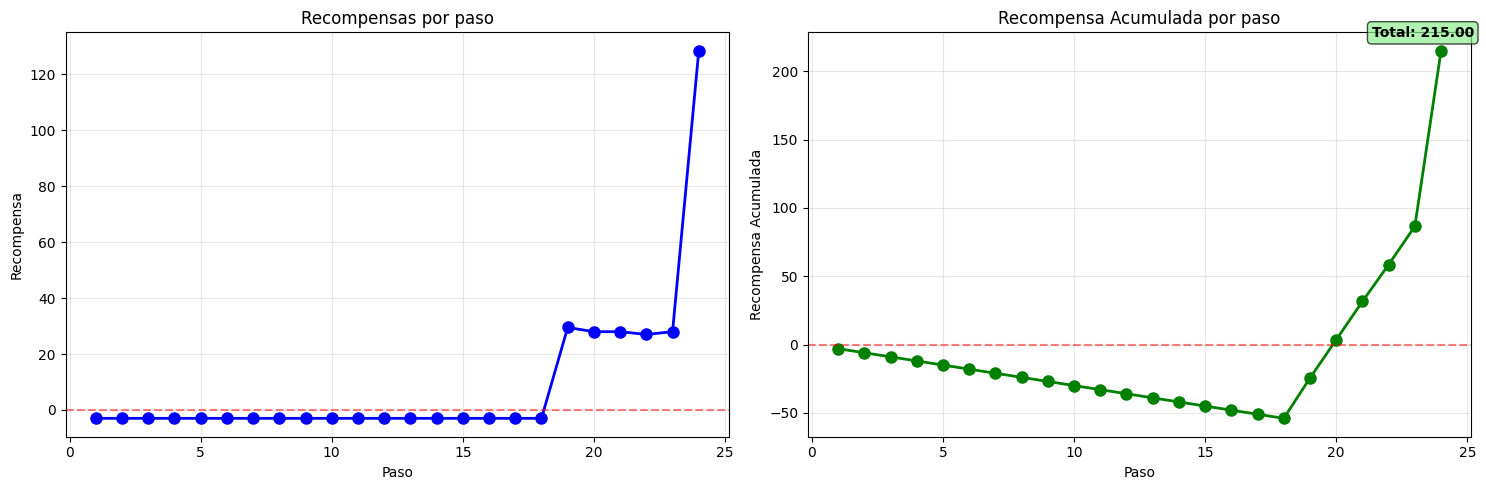

In [ ]:
# Crear entorno
env = EntornoDecisionGlobal(N=3, max_pasos=25)

# Política fija para demostración
def politica_fija(paso):
    """
    Política de exploración:
    - Pasos 0-3: Todos observan
    - Pasos 4-7: Todos consultan
    - Paso 8+: Todos deciden
    """
    if paso < 18:
        return ['observar', 'observar', 'observar']
    elif paso == 19:
        return ['consultar', 'observar', 'consultar']
    elif paso == 20:
        return ['consultar', 'consultar', 'observar']
    elif paso == 21:
        return ['observar', 'observar', 'observar']
    elif paso == 22:
        return ['consultar', 'observar', 'consultar']
    elif paso == 23:
        return ['decidir', 'consultar', 'observar']
    elif paso == 24:
        return ['consultar', 'consultar', 'consultar']
    elif paso < 26:
        return ['consultar', 'decidir', 'decidir']
    else:
        return ['decidir', 'decidir', 'decidir']

# Ejecutar simulación
estado = env.reset()
print("=== SIMULACIÓN CON POLÍTICA FIJA ===\n")
print(f"Estado inicial (creencias de los 3 agentes):")
for i, agente in enumerate(env.agentes):
    print(f"  Agente {i+1}: ({agente.creencia[0]:.2f}, {agente.creencia[1]:.2f})")

print("\n--- EVOLUCIÓN ---")
done = False
paso = 0

while not done:
    acciones = politica_fija(paso)
    nuevo_estado, recompensa, done, info = env.step(acciones)

    print(f"\nPaso {paso + 1}:")
    print(f"  Acciones: {acciones}")
    print(f"  Recompensa: {recompensa:.2f}")
    print(f"  Creencias actuales:")
    for i, creencia in enumerate(info['creencias']):
        print(f"    Agente {i+1}: ({creencia[0]:.2f}, {creencia[1]:.2f})")
    if any(d is not None for d in info['decisiones']):
        print(f"  Decisiones: {info['decisiones']}")
    paso += 1

print(f"\n=== EPISODIO COMPLETADO en {paso} pasos ===")

# Visualizar trayectorias (gráfico único)
env.visualizar_trayectorias("Trayectorias de los Agentes - Política Fija")

# Visualizar evolución detallada (subplots)
env.visualizar_evolucion()

In [ ]:
env.historial_creencias

[[array([4.49291779, 0.31587414]),
  array([0.06125534, 3.23625287]),
  array([1.40079741, 1.51425739])],
 [array([3.84802871, 0.81634344]),
  array([0.70739117, 3.35243956]),
  array([1.85564573, 2.19371464])],
 [array([3.50061765, 1.17320329]),
  array([1.17322309, 2.91562269]),
  array([2.20040908, 2.69882559])],
 [array([3.08220006, 1.48667264]),
  array([2.24024962, 2.77201252]),
  array([2.68651622, 3.26908112])],
 [array([2.96020571, 1.63309026]),
  array([1.86570647, 2.63282276]),
  array([2.75945731, 2.57151811])],
 [array([2.93888534, 1.96057699]),
  array([1.92856601, 2.67496922]),
  array([2.26226858, 1.71663931])],
 [array([2.80867824, 2.08706995]),
  array([1.68728638, 2.63901661]),
  array([2.48188581, 1.54035828])],
 [array([2.61241127, 2.17584276]),
  array([2.25684157, 2.63979307]),
  array([2.52684808, 2.06494985])],
 [array([2.51585736, 2.46005206]),
  array([2.83309067, 2.36899772]),
  array([2.33770101, 1.87938989])],
 [array([2.63726405, 2.55141628]),
  array([2.

=== ANIMACIÓN COMPLETADA ===
Recompensa total: 215.00


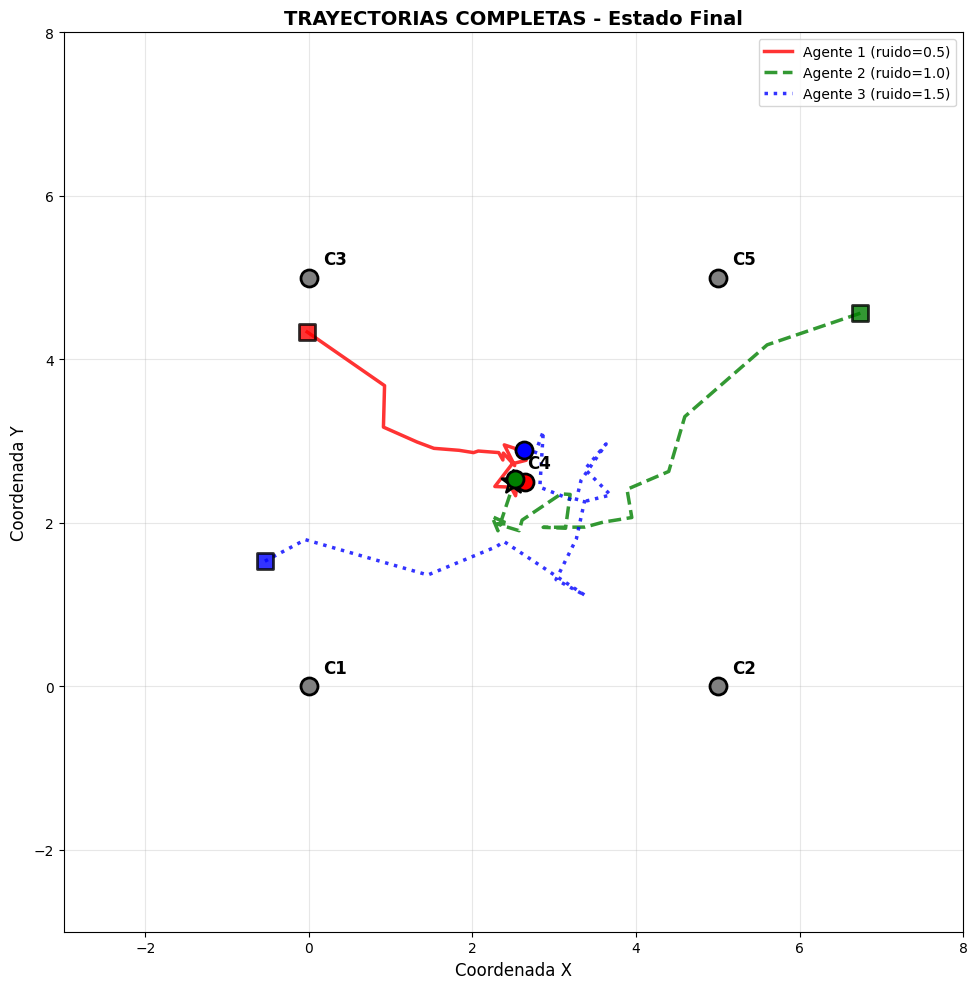

In [ ]:
import time
from IPython.display import clear_output
import matplotlib.pyplot as plt
import numpy as np

def animacion_tiempo_real(env, centroides, centroide_objetivo, velocidad=0.5):
    """
    Muestra la evolución paso a paso en tiempo real con clear_output.

    Parámetros:
    - env: entorno con historial de creencias
    - centroides: diccionario con los centroides
    - centroide_objetivo: índice del centroide objetivo
    - velocidad: tiempo de pausa entre pasos (segundos)
    """
    n_pasos = len(env.historial_creencias)

    # Colores y estilos
    colores = ['red', 'green', 'blue']
    estilos = ['-', '--', ':']
    nombres = ['Agente 1 (ruido=0.5)', 'Agente 2 (ruido=1.0)', 'Agente 3 (ruido=1.5)']

    for paso in range(n_pasos):
        # Limpiar output anterior
        clear_output(wait=True)

        # Crear figura
        fig, ax = plt.subplots(figsize=(12, 10))

        # Dibujar centroides
        for idx, coord in centroides.items():
            color = 'gold' if idx == centroide_objetivo else 'gray'
            size = 300 if idx == centroide_objetivo else 150
            marker = '*' if idx == centroide_objetivo else 'o'
            ax.scatter(coord[0], coord[1], c=color, s=size, marker=marker,
                       edgecolors='black', linewidth=2, zorder=5)
            ax.annotate(f'C{idx+1}', coord, xytext=(10, 10), textcoords='offset points',
                        fontsize=12, fontweight='bold')

        # Dibujar trayectoria completa hasta el paso actual
        for i in range(3):
            x_data = [env.historial_creencias[t][i][0] for t in range(paso + 1)]
            y_data = [env.historial_creencias[t][i][1] for t in range(paso + 1)]

            # Línea de trayectoria
            ax.plot(x_data, y_data, color=colores[i], linestyle=estilos[i],
                   linewidth=2.5, alpha=0.7, label=nombres[i])

            # Punto actual
            ax.scatter(x_data[-1], y_data[-1], c=colores[i], s=150, marker='o',
                      edgecolors='black', linewidth=2, zorder=6)

        # Marcar inicio
        for i in range(3):
            x_inicio = env.historial_creencias[0][i][0]
            y_inicio = env.historial_creencias[0][i][1]
            ax.scatter(x_inicio, y_inicio, c=colores[i], s=100, marker='s',
                      edgecolors='black', linewidth=1.5, alpha=0.7, zorder=5)

        # Configurar gráfico
        ax.set_xlim(-3, 8)
        ax.set_ylim(-3, 8)
        ax.set_xlabel('Coordenada X', fontsize=12)
        ax.set_ylabel('Coordenada Y', fontsize=12)
        ax.set_title(f'Evolución Temporal - Paso {paso}/{n_pasos-1}', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.set_aspect('equal')
        ax.legend(loc='upper right', fontsize=10)

        # Mostrar acciones del paso actual
        if hasattr(env, 'historial_acciones') and paso < len(env.historial_acciones):
            acciones = env.historial_acciones[paso]
            ax.text(0.02, 0.95, f'Acciones: {acciones}', transform=ax.transAxes,
                   fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

        # Mostrar información de recompensa
        recompensa_acum = sum(env.historial_recompensas[:paso+1]) if env.historial_recompensas else 0
        info_text = f"Paso: {paso}\nRecompensa acumulada: {recompensa_acum:.2f}"
        ax.text(0.02, 0.02, info_text, transform=ax.transAxes, fontsize=10,
               verticalalignment='bottom', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

        plt.show()

        # Pausa para controlar velocidad
        time.sleep(velocidad)

    # Mostrar gráfico final estático
    clear_output(wait=True)

    print("=== ANIMACIÓN COMPLETADA ===")
    print(f"Recompensa total: {sum(env.historial_recompensas):.2f}")

    # Gráfico final estático
    fig, ax = plt.subplots(figsize=(12, 10))

    # Dibujar centroides
    for idx, coord in centroides.items():
        color = 'gold' if idx == centroide_objetivo else 'gray'
        size = 300 if idx == centroide_objetivo else 150
        marker = '*' if idx == centroide_objetivo else 'o'
        ax.scatter(coord[0], coord[1], c=color, s=size, marker=marker,
                   edgecolors='black', linewidth=2, zorder=5)
        ax.annotate(f'C{idx+1}', coord, xytext=(10, 10), textcoords='offset points',
                    fontsize=12, fontweight='bold')

    # Dibujar trayectorias COMPLETAS
    for i in range(3):
        x_data = [env.historial_creencias[t][i][0] for t in range(n_pasos)]
        y_data = [env.historial_creencias[t][i][1] for t in range(n_pasos)]

        ax.plot(x_data, y_data, color=colores[i], linestyle=estilos[i],
               linewidth=2.5, alpha=0.8, label=nombres[i])

        # Punto inicial (cuadrado)
        ax.scatter(x_data[0], y_data[0], c=colores[i], s=120, marker='s',
                  edgecolors='black', linewidth=2, zorder=6, alpha=0.8)

        # Punto final (círculo)
        ax.scatter(x_data[-1], y_data[-1], c=colores[i], s=150, marker='o',
                  edgecolors='black', linewidth=2, zorder=6)

    ax.set_xlim(-3, 8)
    ax.set_ylim(-3, 8)
    ax.set_xlabel('Coordenada X', fontsize=12)
    ax.set_ylabel('Coordenada Y', fontsize=12)
    ax.set_title('TRAYECTORIAS COMPLETAS - Estado Final', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=10)

    plt.tight_layout()
    plt.show()

# Ejecutar animación en tiempo real
print("=== ANIMACIÓN EN TIEMPO REAL ===\n")
animacion_tiempo_real(env, centroides, centroide_objetivo, velocidad=0.3)